<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan9_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 9
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# =====================================================================
# LANGKAH 1: LOAD & EDA SINGKAT
# =====================================================================
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0 = Malignant (Ganas), 1 = Benign (Jinak)

print('=== Eksplorasi Awal Data ===')
print('Shape Data (Baris, Kolom):', X.shape)
print('\nDistribusi Target (0: Ganas, 1: Jinak):')
print(pd.Series(y).value_counts(normalize=True).round(3))

# =====================================================================
# LANGKAH 2: PREPROCESSING (DATA SPLITTING & SCALING)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('\n✅ Preprocessing Selesai. Data siap dimasukkan ke dalam model.')

=== Eksplorasi Awal Data ===
Shape Data (Baris, Kolom): (569, 30)

Distribusi Target (0: Ganas, 1: Jinak):
1    0.627
0    0.373
Name: proportion, dtype: float64

✅ Preprocessing Selesai. Data siap dimasukkan ke dalam model.


=== 5 Fitur Paling Berpengaruh pada Logistic Regression ===
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616

=== Laporan Klasifikasi Logistic Regression ===
                   precision    recall  f1-score   support

Malignant (Ganas)       0.98      0.98      0.98        42
   Benign (Jinak)       0.99      0.99      0.99        72

         accuracy                           0.98       114
        macro avg       0.98      0.98      0.98       114
     weighted avg       0.98      0.98      0.98       114



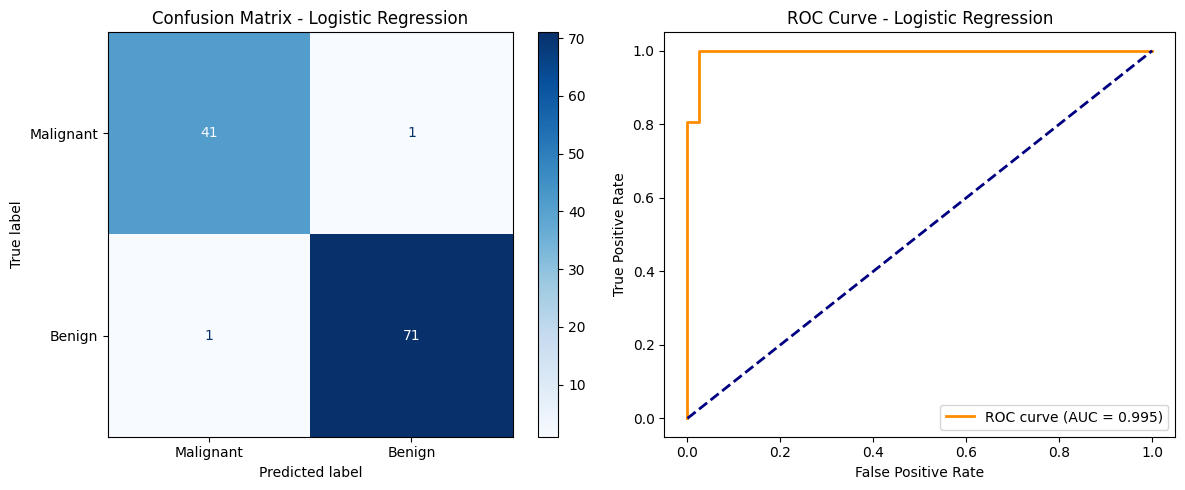

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# =====================================================================
# LANGKAH 3: LATIH LOGISTIC REGRESSION
# =====================================================================
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
y_prob_log = log_model.predict_proba(X_test_s)[:, 1]

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
})

coef_df['Abs_Koefisien'] = coef_df['Koefisien'].abs()
coef_df = coef_df.sort_values('Abs_Koefisien', ascending=False).drop('Abs_Koefisien', axis=1)

print('=== 5 Fitur Paling Berpengaruh pada Logistic Regression ===')
print(coef_df.head().to_string(index=False))

print('\n=== Laporan Klasifikasi Logistic Regression ===')
print(classification_report(y_test, y_pred_log, target_names=['Malignant (Ganas)', 'Benign (Jinak)']))

# Visualisasi Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=['Malignant', 'Benign']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Logistic Regression')

fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

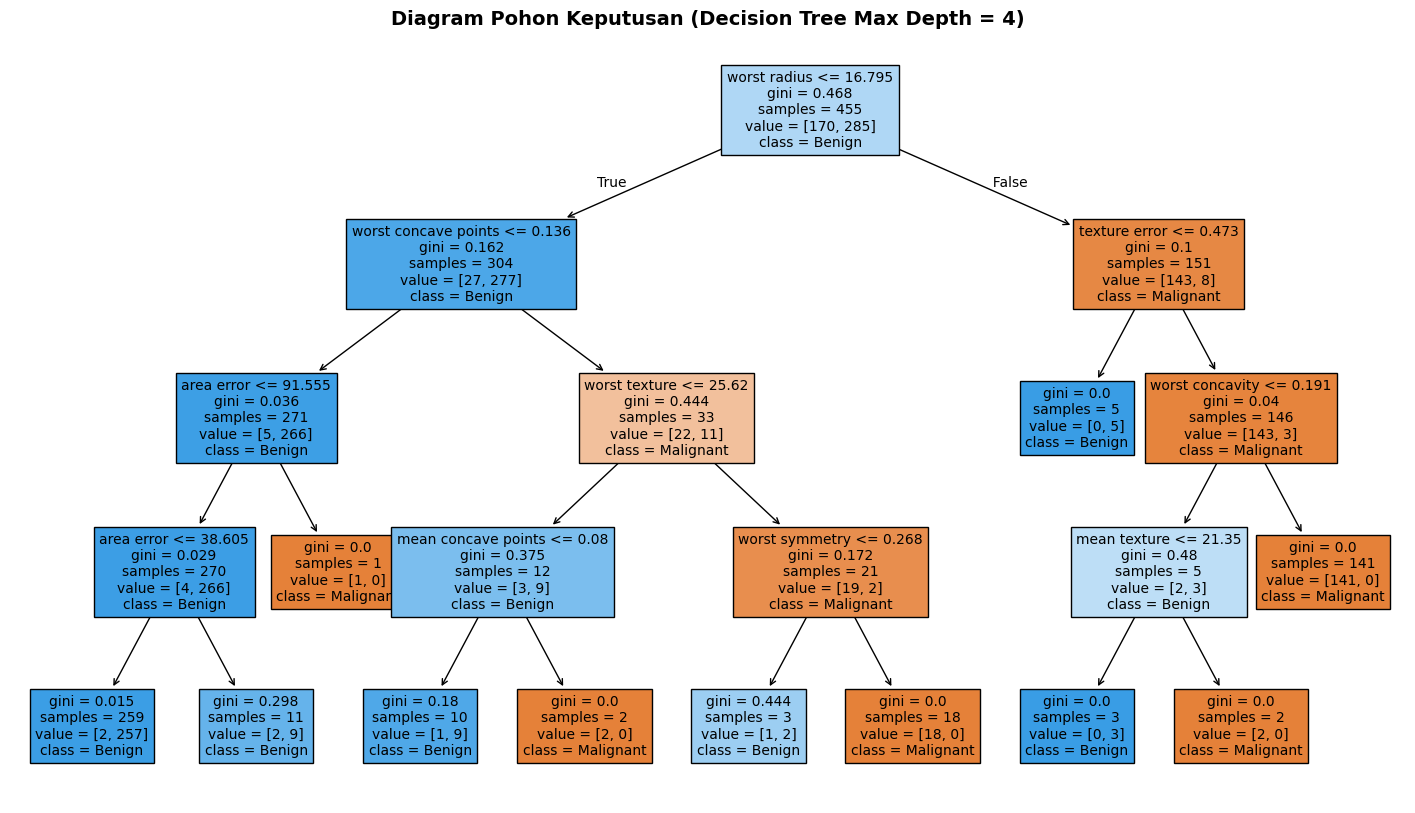


=== Laporan Klasifikasi Decision Tree ===
                   precision    recall  f1-score   support

Malignant (Ganas)       0.91      0.93      0.92        42
   Benign (Jinak)       0.96      0.94      0.95        72

         accuracy                           0.94       114
        macro avg       0.93      0.94      0.93       114
     weighted avg       0.94      0.94      0.94       114



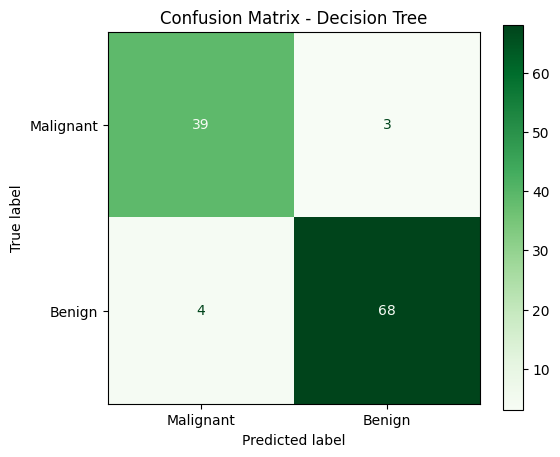

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# LANGKAH 4: LATIH DECISION TREE & VISUALISASI
# =====================================================================
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    fontsize=10
)
plt.title('Diagram Pohon Keputusan (Decision Tree Max Depth = 4)', fontsize=14, fontweight='bold')
plt.show()

print('\n=== Laporan Klasifikasi Decision Tree ===')
print(classification_report(y_test, y_pred_tree, target_names=['Malignant (Ganas)', 'Benign (Jinak)']))

# Visualisasi Confusion Matrix Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(cm_tree, display_labels=['Malignant', 'Benign']).plot(ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix - Decision Tree')
plt.show()

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================================
# LANGKAH 5: EVALUASI DAN PERBANDINGAN MODEL
# =====================================================================
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Akurasi': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
}

df_comparison = pd.DataFrame(metrics_data)
print('=== Perbandingan Kinerja Model ===')
print(df_comparison.round(4).to_string(index=False))

=== Perbandingan Kinerja Model ===
              Model  Akurasi  Precision  Recall  F1-Score
Logistic Regression   0.9825     0.9861  0.9861    0.9861
      Decision Tree   0.9386     0.9577  0.9444    0.9510


## **Kesimpulan & Refleksi Akhir**

* **Apa yang Dipelajari:** Membandingkan model Logistic Regression dan Decision Tree pada kasus klasifikasi medis, serta memahami pentingnya metrik evaluasi Recall dan visualisasi struktur pohon keputusan untuk transparansi model AI.
* **Temuan Utama:** Logistic Regression terbukti lebih optimal untuk dataset ini dengan akurasi 98.2% dan Recall hingga 98.6% (pada kelas Benign) / 97.6% (pada kelas Malignant). Melalui data, ditemukan bahwa karakteristik ukuran fisik luar sel (*worst radius*) dan tekstur sel (*worst texture*) merupakan indikator paling krusial dalam mendeteksi keganasan kanker.
* **Keterbatasan & Pertanyaan:**
  * **Keterbatasan:** Model Decision Tree (`max_depth=4`) masih meloloskan 3 pasien kanker ganas sebagai pasien sehat (*False Negative*), tingkat risiko yang masih terlalu tinggi untuk standar medis nyata.
  * **Pertanyaan:** Bagaimana cara menaikkan nilai Recall hingga mencapai angka sempurna 100% tanpa merusak performa akurasi umumnya secara ekstrem?